In [1]:
# Author: Remi Flamary <remi.flamary@unice.fr>
#
# License: MIT License
# sphinx_gallery_thumbnail_number = 3

import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot
from ot.datasets import make_1D_gauss as gauss

### Generate data


In [2]:
n = 100         # number of bins

# bin positions
x = np.arange(n, dtype=np.float64)

# Gaussian distributions
a = gauss(n, m=20, s=5)             # m = mean, s = standard deviation
b = gauss(n, m=60, s=10)

# Loss matrix
M = ot.dist(x.reshape((n,1)), x.reshape((n,1)))
M /= M.max()

### Plot distributions and loss matrix

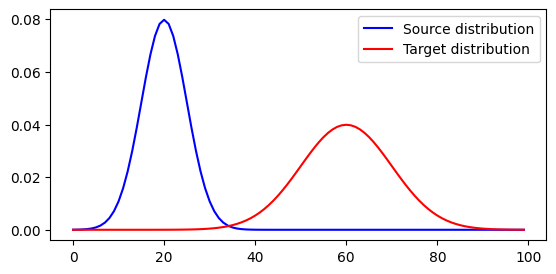

In [3]:
pl.figure(1, figsize=(6.4, 3))
pl.plot(x, a, "b", label="Source distribution")
pl.plot(x, b, "r", label="Target distribution")
pl.legend()

(<Axes: >, <Axes: >, <Axes: >)

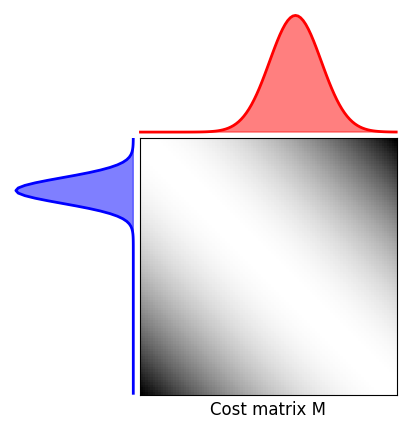

In [4]:
pl.figure(2, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, M, "Cost matrix M")

(<Axes: >, <Axes: >, <Axes: >)

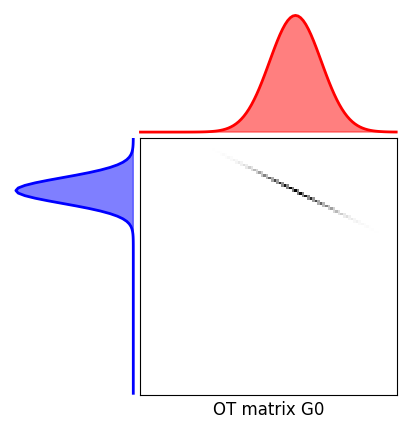

In [5]:
# use fast 1D solver
G0 = ot.emd_1d(x, x, a, b)      # Equivalent to G0 = ot.emd(a, b, M)


pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, G0, "OT matrix G0")

### Solve Sinkhorn

It.  |Err         
-------------------
    0|2.861463e-01|
   10|1.860154e-01|
   20|8.144529e-02|
   30|3.130143e-02|
   40|1.178815e-02|
   50|4.426078e-03|
   60|1.661047e-03|
   70|6.233110e-04|
   80|2.338932e-04|
   90|8.776627e-05|
  100|3.293340e-05|
  110|1.235791e-05|
  120|4.637176e-06|
  130|1.740051e-06|
  140|6.529356e-07|
  150|2.450071e-07|
  160|9.193632e-08|
  170|3.449812e-08|
  180|1.294505e-08|
  190|4.857493e-09|
It.  |Err         
-------------------
  200|1.822723e-09|


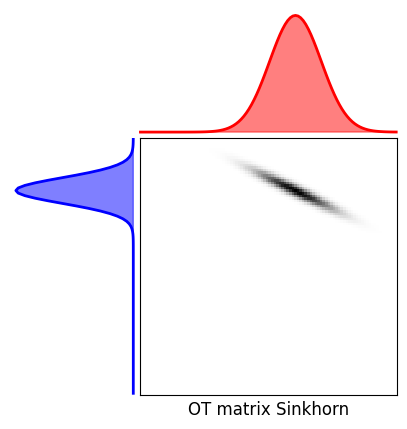

In [6]:
lambd = 1e-3
Gs = ot.sinkhorn(a, b, M, lambd, verbose=True)

pl.figure(4, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gs, "OT matrix Sinkhorn")

pl.show()

### Solve Smooth OT

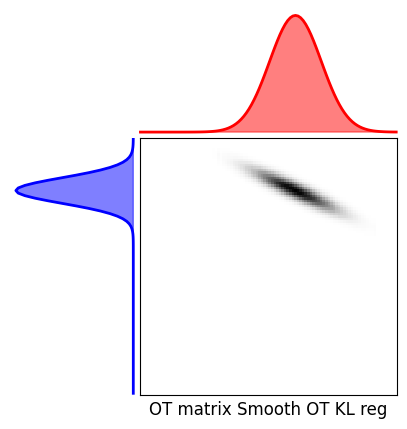

In [8]:
lambd = 2e-3
Gsm = ot.smooth.smooth_ot_dual(a, b, M, lambd, reg_type="kl")

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsm, "OT matrix Smooth OT KL reg")

pl.show()

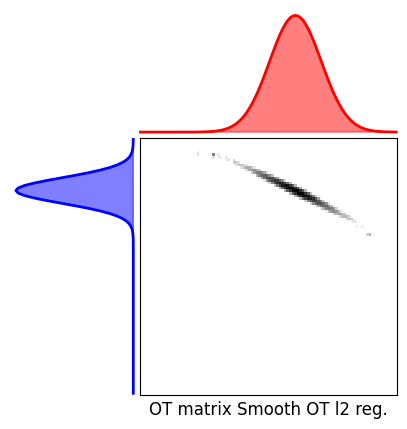

In [9]:
lambd = 1e-1
Gsm = ot.smooth.smooth_ot_dual(a, b, M, lambd, reg_type="l2")

pl.figure(5, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsm, "OT matrix Smooth OT l2 reg.")

pl.show()

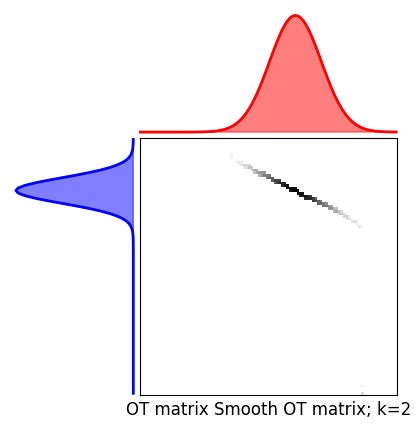

In [10]:
lambd = 1e-1

max_nz = 2    # two non-zero entries are permitted per column of the OT plan
Gsc = ot.smooth.smooth_ot_dual(
    a, b, M, lambd, reg_type="sparsity_constrained", max_nz=max_nz
)
pl.figure(6, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsc, "OT matrix Smooth OT matrix; k=2")

pl.show()